✓ numpy already installed
✓ pandas already installed
✓ matplotlib already installed
✓ seaborn already installed
Installing scikit-learn...
All libraries loaded successfully.
Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


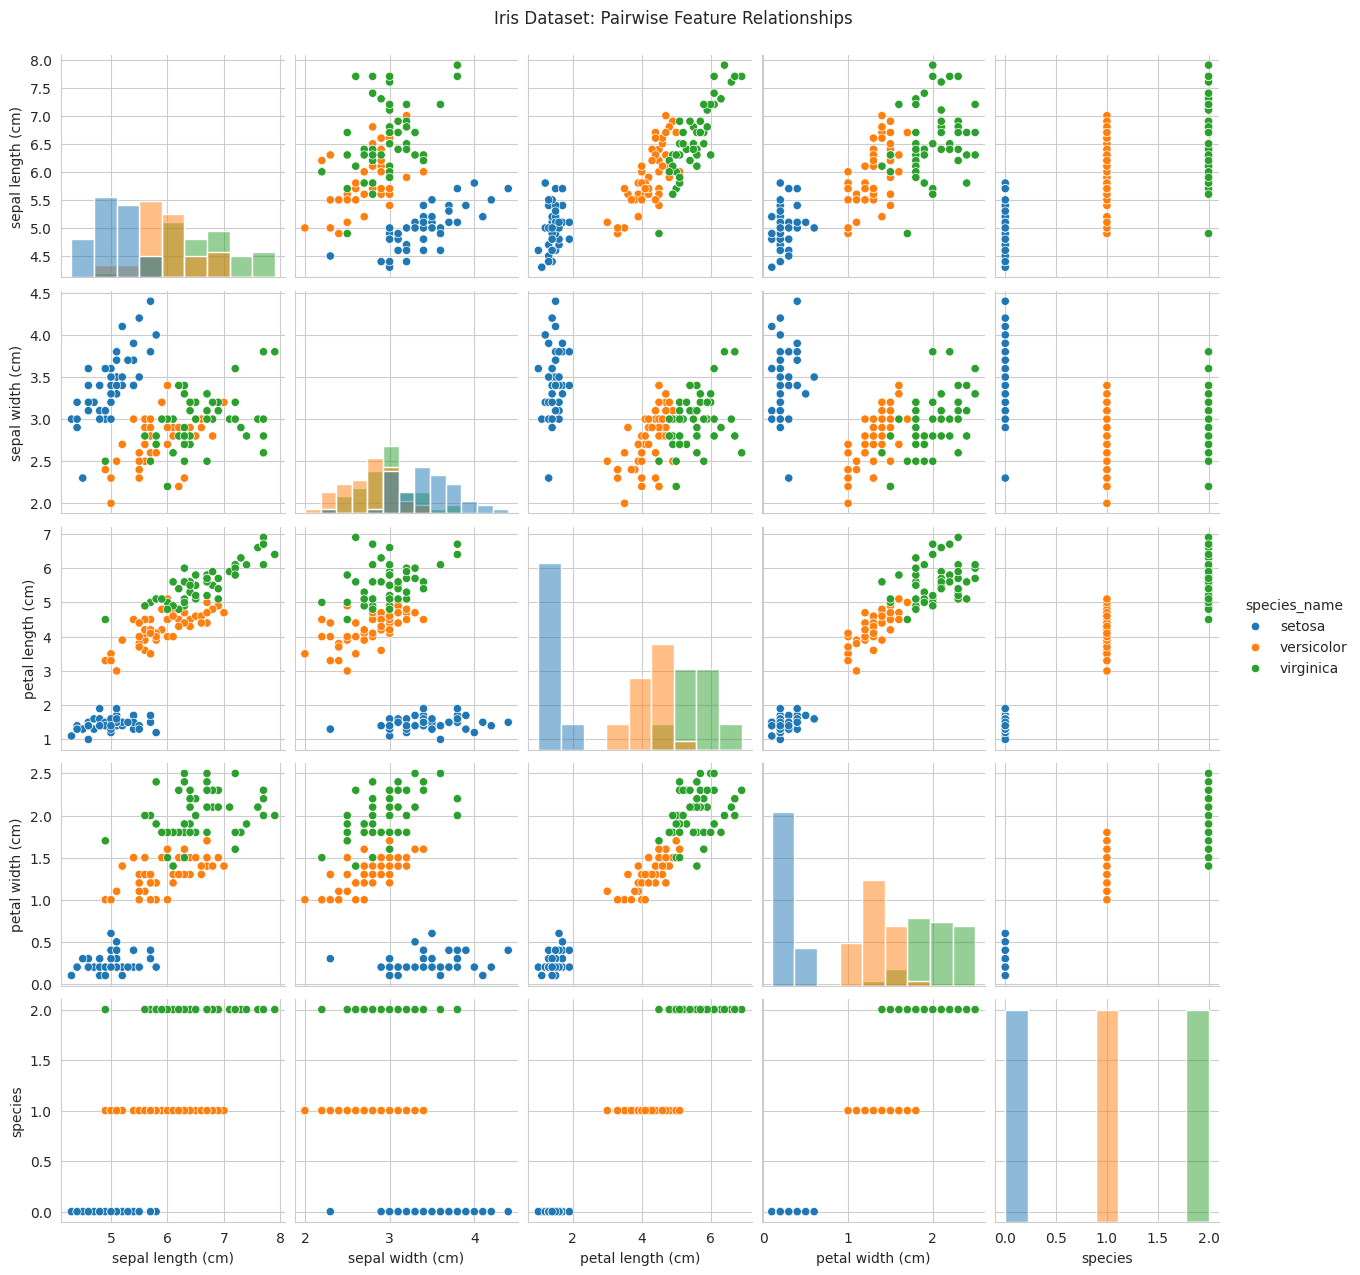

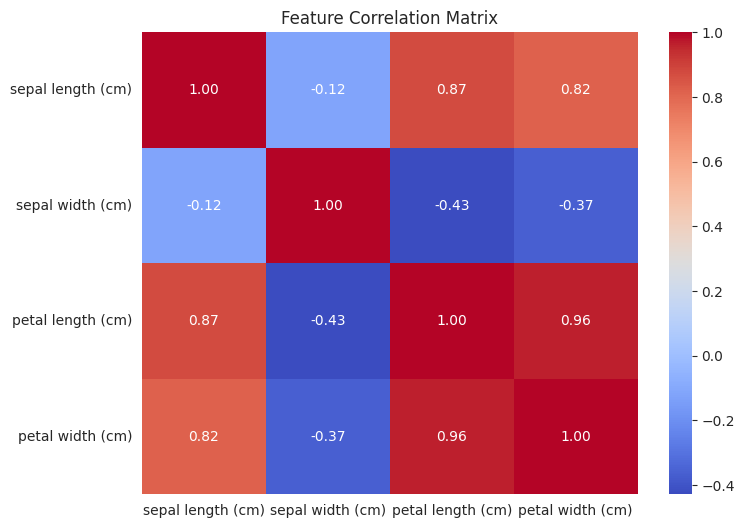

Training samples: 120, Test samples: 30

Classifier: Logistic Regression
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



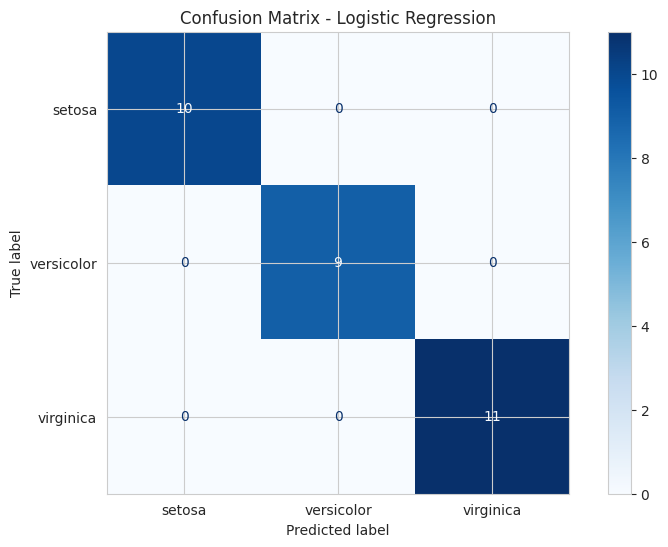


Classifier: K-Nearest Neighbors (k=5)
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



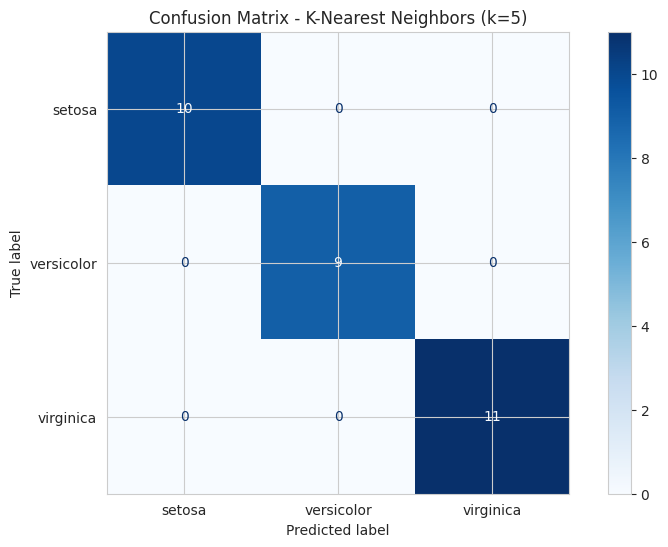


Classifier: Decision Tree
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



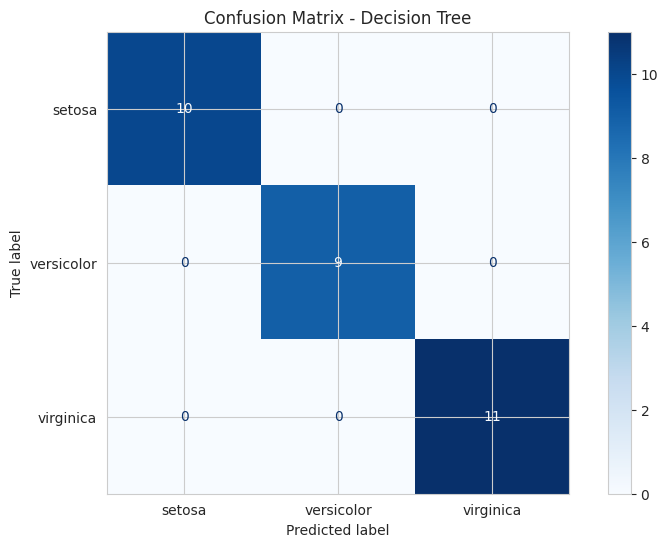


Classifier: Random Forest
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



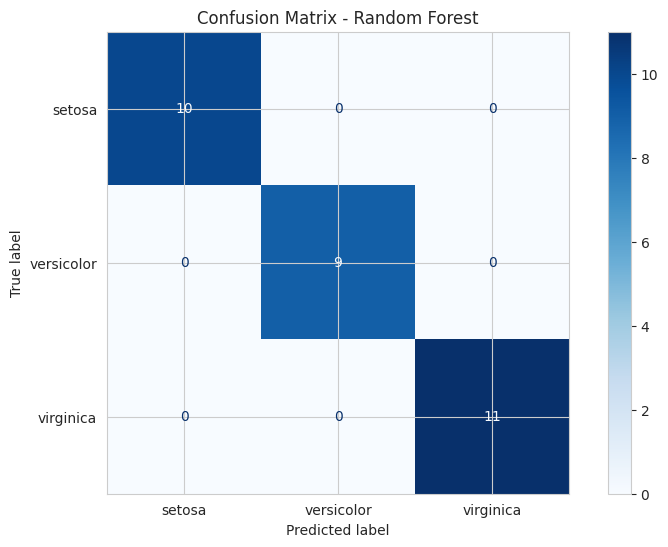


Classifier: Support Vector Machine (RBF)
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



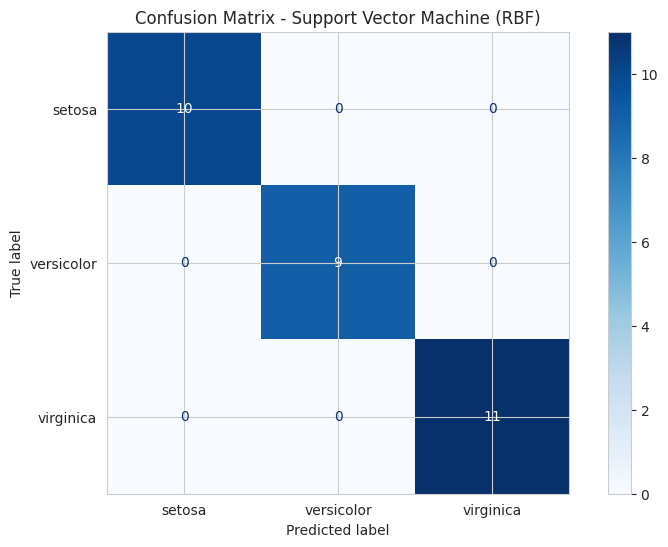


Classifier: Gaussian Naive Bayes
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



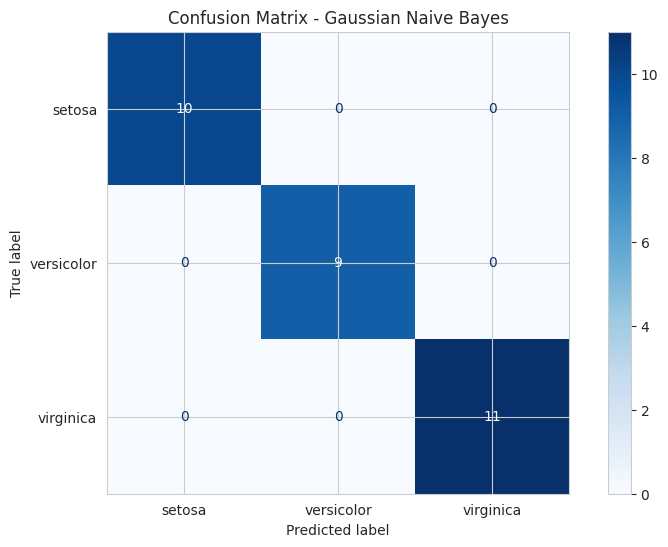


Model Comparison:
            Classifier  Accuracy
0  Logistic Regression       1.0
1                  KNN       1.0
2        Decision Tree       1.0
3        Random Forest       1.0
4                  SVM       1.0
5          Naive Bayes       1.0


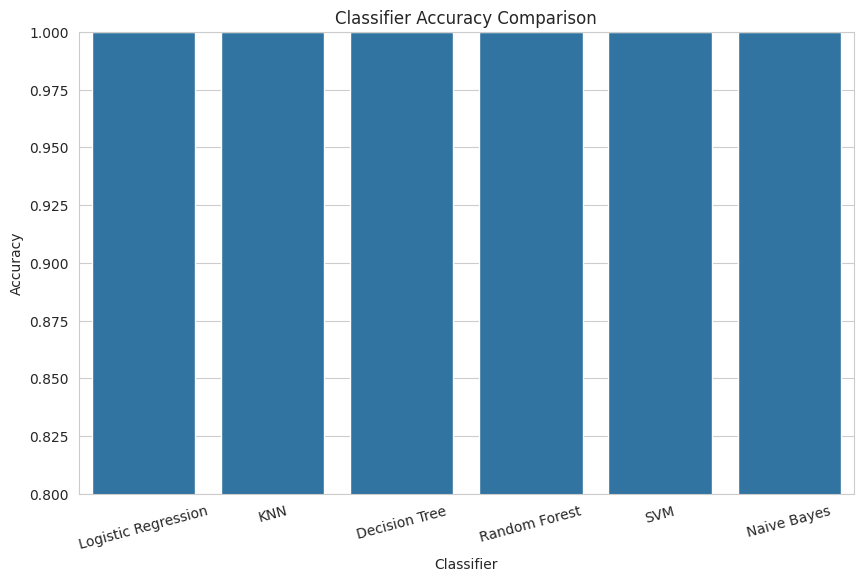


Best Performing Model:
Classifier    Logistic Regression
Accuracy                      1.0
Name: 0, dtype: object


In [1]:
# =========================================
# INSTALL REQUIRED LIBRARIES
# =========================================

import subprocess
import sys
import importlib
import gc
import warnings

warnings.filterwarnings('ignore')


def install_if_missing(package):

    try:
        importlib.import_module(package)

        print(f"✓ {package} already installed")

    except ImportError:

        print(f"Installing {package}...")

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package]
        )


install_if_missing("numpy")
install_if_missing("pandas")
install_if_missing("matplotlib")
install_if_missing("seaborn")
install_if_missing("scikit-learn")


# =========================================
# IMPORT LIBRARIES
# =========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Classification Algorithms
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB


# =========================================
# VISUALIZATION SETTINGS
# =========================================

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries loaded successfully.")


# =========================================
# LOAD IRIS DATASET
# =========================================

iris = load_iris()

X = iris.data

y = iris.target

feature_names = iris.feature_names

target_names = iris.target_names


# =========================================
# DATASET INFORMATION
# =========================================

print("Dataset shape:", X.shape)

print("Features:", feature_names)

print("Target classes:", target_names)


# =========================================
# CREATE DATAFRAME
# =========================================

df = pd.DataFrame(
    X,
    columns=feature_names
)

df['species'] = y

df['species_name'] = df['species'].map(
    {
        i: name
        for i, name in enumerate(target_names)
    }
)

print(df.head())


# =========================================
# PAIRPLOT VISUALIZATION
# =========================================

sns.pairplot(
    df,
    hue='species_name',
    diag_kind='hist'
)

plt.suptitle(
    "Iris Dataset: Pairwise Feature Relationships",
    y=1.02
)

plt.show()


# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.iloc[:, :-2].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Matrix")

plt.show()


# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    f"Training samples: {X_train.shape[0]}, "
    f"Test samples: {X_test.shape[0]}"
)


# =========================================
# FEATURE SCALING
# =========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# =========================================
# CLASSIFIER EVALUATION FUNCTION
# =========================================

def evaluate_classifier(
    clf,
    X_train,
    X_test,
    y_train,
    y_test,
    name
):

    # Train Model
    clf.fit(X_train, y_train)

    # Predictions
    y_pred = clf.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    print("\n" + "=" * 50)

    print(f"Classifier: {name}")

    print(f"Accuracy: {acc:.4f}")

    # Classification Report
    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_names
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_names
    )

    disp.plot(cmap='Blues')

    plt.title(f"Confusion Matrix - {name}")

    plt.show()

    return acc


# =========================================
# LOGISTIC REGRESSION
# =========================================

lr = LogisticRegression(
    max_iter=200,
    random_state=42
)

acc_lr = evaluate_classifier(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Logistic Regression"
)


# =========================================
# K-NEAREST NEIGHBORS
# =========================================

knn = KNeighborsClassifier(
    n_neighbors=5
)

acc_knn = evaluate_classifier(
    knn,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "K-Nearest Neighbors (k=5)"
)


# =========================================
# DECISION TREE
# =========================================

dt = DecisionTreeClassifier(
    random_state=42
)

acc_dt = evaluate_classifier(
    dt,
    X_train,
    X_test,
    y_train,
    y_test,
    "Decision Tree"
)


# =========================================
# RANDOM FOREST
# =========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

acc_rf = evaluate_classifier(
    rf,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)


# =========================================
# SUPPORT VECTOR MACHINE
# =========================================

svm = SVC(
    kernel='rbf',
    random_state=42
)

acc_svm = evaluate_classifier(
    svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Support Vector Machine (RBF)"
)


# =========================================
# GAUSSIAN NAIVE BAYES
# =========================================

nb = GaussianNB()

acc_nb = evaluate_classifier(
    nb,
    X_train,
    X_test,
    y_train,
    y_test,
    "Gaussian Naive Bayes"
)


# =========================================
# COMPARE MODEL ACCURACIES
# =========================================

results = pd.DataFrame({

    'Classifier': [

        'Logistic Regression',

        'KNN',

        'Decision Tree',

        'Random Forest',

        'SVM',

        'Naive Bayes'
    ],

    'Accuracy': [

        acc_lr,

        acc_knn,

        acc_dt,

        acc_rf,

        acc_svm,

        acc_nb
    ]
})

print("\nModel Comparison:")

print(results)


# =========================================
# BARPLOT OF ACCURACIES
# =========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Classifier',
    y='Accuracy',
    data=results
)

plt.title("Classifier Accuracy Comparison")

plt.ylim(0.8, 1.0)

plt.xticks(rotation=15)

plt.show()


# =========================================
# BEST MODEL
# =========================================

best_model = results.loc[
    results['Accuracy'].idxmax()
]

print("\nBest Performing Model:")

print(best_model)